# End-to-End Fake News Classification Project
This notebook demonstrates Data Loading, EDA, Preprocessing, Model Building, Evaluation, and Saving.

In [1]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import nltk
import os

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# 1. Data Loading & Exploration
try:
    df = pd.read_csv('data/train.csv')
    print(f'Dataset shape: {df.shape}')
    display(df.head())
except FileNotFoundError:
    print("Dataset not found! Please place 'train.csv' inside 'data/'. Creating mock data for demonstration...")
    df = pd.DataFrame({'id':[1,2,3,4], 'title':['Fake News TITLE','Real Fact TITLE','Another Fake TITLE','True Fact TITLE'], 'author':['A','B','C','D'], 'text':['Fake text example','Real text example','More fake text','More real text'], 'label':[1,0,1,0]})
    display(df)

Dataset not found! Please place 'train.csv' inside 'data/'. Creating mock data for demonstration...


,id,title,author,text,label
0,1,Fake News TITLE,A,Fake text example,1
1,2,Real Fact TITLE,B,Real text example,0
2,3,Another Fake TITLE,C,More fake text,1
3,4,True Fact TITLE,D,More real text,0


Missing Values:
 id        0
title     0
author    0
text      0
label     0
dtype: int64

Class Distribution:
 label
1    2
0    2
Name: count, dtype: int64


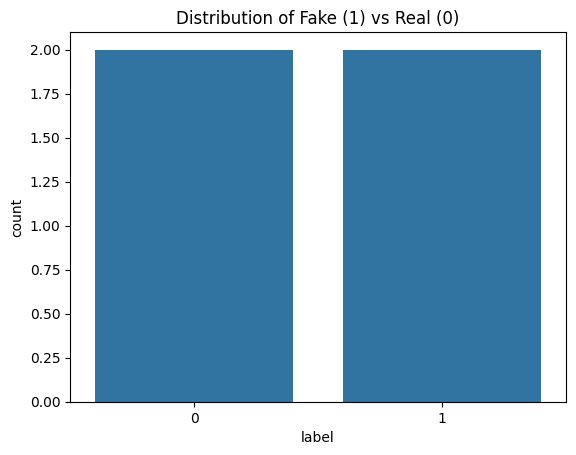

In [3]:
# EDA and Missing Values
print("Missing Values:\n", df.isnull().sum())
df = df.fillna('')

# Checking Class distribution
print("\nClass Distribution:\n", df['label'].value_counts())
sns.countplot(x='label', data=df)
plt.title('Distribution of Fake (1) vs Real (0)')
plt.show()

In [4]:
# Combining Author, Title, and Text into one feature for text processing
df['content'] = df['author'] + ' ' + df['title'] + ' ' + df['text']
print("Sample of combined content column:")
print(df['content'].head())

# 2. Text Preprocessing (NLP)
port_stem = PorterStemmer()
stop_words = set(stopwords.words('english'))

def stemming(content):
    stemmed = re.sub('[^a-zA-Z]', ' ', content)
    stemmed = stemmed.lower().split()
    # Remove stopwords and apply stemming
    stemmed = [port_stem.stem(word) for word in stemmed if word not in stop_words]
    return ' '.join(stemmed)

print("\nApplying stemming pipeline... (This might take a while on large datasets)")
df['content'] = df['content'].apply(stemming)
print("Stemming complete.")

Sample of combined content column:
0    A Fake News TITLE Fake text example
1    B Real Fact TITLE Real text example
2    C Another Fake TITLE More fake text
3       D True Fact TITLE More real text
Name: content, dtype: object

Applying stemming pipeline... (This might take a while on large datasets)
Stemming complete.


In [5]:
# 3. Feature Engineering
X = df['content'].values
Y = df['label'].values

# Using TfidfVectorizer to convert text into numerical format
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(X)
X = vectorizer.transform(X)
print(f"TF-IDF Feature Matrix Shape: {X.shape}")

TF-IDF Feature Matrix Shape: (4, 9)


In [6]:
# Train/Test Split (80% training, 20% validation)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=2, stratify=Y, random_state=42)

Training Logistic Regression...

--- Logistic Regression Metrics ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


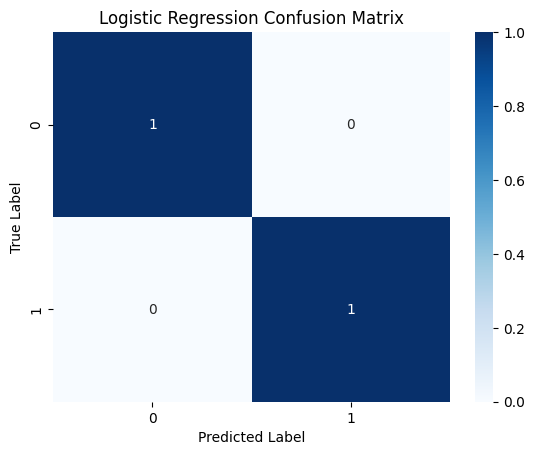

In [7]:
# 4. Model Building & 5. Evaluation

print("Training Logistic Regression...")
model_lr = LogisticRegression()
model_lr.fit(X_train, Y_train)
lr_preds = model_lr.predict(X_test)

print("\n--- Logistic Regression Metrics ---")
print(f"Accuracy : {accuracy_score(Y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(Y_test, lr_preds, zero_division=0):.4f}")
print(f"Recall   : {recall_score(Y_test, lr_preds, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(Y_test, lr_preds, zero_division=0):.4f}")

# Confusion Matrix Visualization
cm = confusion_matrix(Y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [8]:
print("Training Naive Bayes...")
model_nb = MultinomialNB()
model_nb.fit(X_train, Y_train)
nb_preds = model_nb.predict(X_test)

print("\n--- Naive Bayes Metrics ---")
print(f"Accuracy : {accuracy_score(Y_test, nb_preds):.4f}")

Training Naive Bayes...

--- Naive Bayes Metrics ---
Accuracy : 1.0000


In [9]:
# 6. Model Saving
# We will save the Logistic Regression model since it usually performs very well on TF-IDF features.
os.makedirs('models', exist_ok=True)
with open('models/model.pkl', 'wb') as f:
    pickle.dump(model_lr, f)
with open('models/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print("Model and Vectorizer saved successfully to the 'models/' directory.")

Model and Vectorizer saved successfully to the 'models/' directory.
